## 7. Supplement Figure 3: Speed At Home, Previous trial reward, Remote At Home

In [22]:
%reload_ext autoreload
%autoreload 2

[17:10:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[17:10:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[17:10:50][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


In [2]:
import numpy as np
import pandas as pd
import pickle
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import ranksums

In [37]:
from spyglass.shijiegu.Analysis_SGU import get_linearization_map

from spyglass.shijiegu.Analysis_SGU import TrialChoice, DecodeIngredients, DecodeResults2D, ChangeofMindTheta, DecodeResultsLinear
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.decoding.v0.visualization import make_single_environment_movie
from spyglass.shijiegu.changeOfMind_triggered_position import load_triggered_position_decode_day
from spyglass.shijiegu.changeOfMind_triggered import linear_map, select_subset_helper_position
from spyglass.shijiegu.changeOfMind_remote import find_posterior_sum_segment, find_remote_theta_animal_new

In [4]:
# Algorithm
# for each trial:
# select time bins the animal is running outbound at 4 cm/s on home arm
#     for each home arm bins:
#        use 1D position info to find sum across time bins that animal is in that home arm bin
#        sum posterior at all bins within home arm
#

In [4]:
params = {"use_1d": False, 
          "use_home": True,
          "use_center": False,
          "use_outer": False,
          "proportion":0.1,
          "delta_t_minus":5,
          "delta_t_plus":0,
          "speed_threshold":4,
          "segment_only":False,
          "max_flag": 0}

In [23]:
animal = "eliot"
list_of_days = ["20221020"]

encoding_set = '2Dheadspeed_above_4_andlowmua'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [6]:
animal = 'Lewis'
list_of_days = ['20240110']

encoding_set = '2Dheadspeed_above_4'
classifier_param_name = 'default_decoding_gpu_4armMaze'

In [8]:
posterior_home_all, home_positions = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,**params)

posterior_home_control_all, _ = find_remote_theta_animal_new(
    animal,list_of_days,classifier_param_name,encoding_set,control = True,**params)

[13:50:22][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[2025-10-01 13:50:22,894][WARNING]: Skipped checksum for file with hash: 50216eb9-c3f8-b02a-5e4b-ea4d877de362, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_DLPP1TUZF2.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/lewis_triggered_position_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240110_p0.1_tm5_tp0_maxflag0_controlFalse_allposterior.pkl':
*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240110_ 2         0.1            0              2              0            lewis20240110_
 (Total: 1)

working on event_index0
working on event_index1
working on event_index2
working on event_index3
working on event_index4
working on event_index5
working on event_index6
working on event_index7
working on event_index8
working on event_index9
working on event_index10
working on event_index11
working on event_index12


[2025-10-01 13:50:47,140][WARNING]: Skipped checksum for file with hash: 83c1b605-6c95-7134-b279-f9ae5da1af01, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_MW7DXODPPJ.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240110_ 4         0.1            0              2              0            lewis20240110_
 (Total: 1)

working on event_index13
working on event_index14
working on event_index15
working on event_index16
working on event_index17
working on event_index18
working on event_index19
working on event_index20
working on event_index21
working on event_index22
working on event_index23
working on event_index24
working on event_index25
working on event_index26
working on event_index27


[2025-10-01 13:51:15,922][WARNING]: Skipped checksum for file with hash: 74fff9e7-c971-1ac1-744b-523fc2eecd74, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_SDFSE0I28N.nwb


...

*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240110_ 6         0.1            0              2              0            lewis20240110_
 (Total: 1)

working on event_index28
working on event_index29
working on event_index30
working on event_index31
working on event_index32
working on event_index33
working on event_index34
working on event_index35
working on event_index36
working on event_index37


[2025-10-01 13:53:11,531][WARNING]: Skipped checksum for file with hash: 1f8190b7-3abd-0a05-7b24-fe01612d84d5, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_HSK7F8R3AM.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240110_ 8         0.1            0              2              0            lewis20240110_
 (Total: 1)

working on event_index38
working on event_index39


[2025-10-01 13:53:23,084][WARNING]: Skipped checksum for file with hash: 434b1b44-3c36-12b5-96fa-f6b83805f4bb, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_UJHAFHTB8Y.nwb


*nwb_file_name *epoch    *proportion    *delta_t_minus *delta_t_plus  *max_flag    analysis_file_
+------------+ +-------+ +------------+ +------------+ +------------+ +----------+ +------------+
lewis20240110_ 10        0.1            0              2              0            lewis20240110_
 (Total: 1)

working on event_index40
working on event_index41
working on event_index42
working on event_index43


Text(0.5, 0, 'home arm location (cm)')

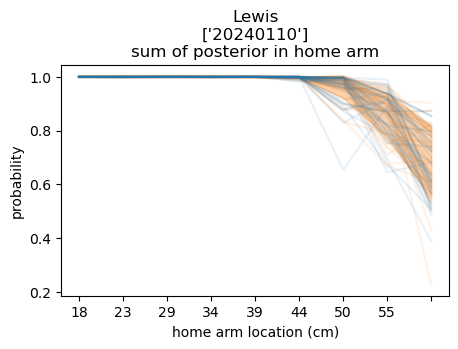

In [21]:
fig,axes = plt.subplots(1,1,figsize = (5,3))

posterior_home_all_np = np.array(posterior_home_all).squeeze()
posterior_home_control_all_np = np.array(posterior_home_control_all).squeeze()

mean = np.mean(posterior_home_all_np, axis = 0)
sd = np.std(posterior_home_all_np, axis = 0)

mean_control = np.mean(posterior_home_control_all_np, axis = 0)
sd_control = np.std(posterior_home_control_all_np, axis = 0)

for posterior_home in posterior_home_all_np:
    axes.plot(posterior_home, 'C1', alpha = 0.1)
axes.fill_between(np.arange(len(posterior_home)), mean - sd, mean + sd, alpha = 0.3, color = 'C1')

for posterior_home in posterior_home_control_all_np:
    axes.plot(posterior_home, 'C0', alpha = 0.1)
axes.fill_between(np.arange(len(posterior_home)), mean_control - sd_control, mean_control + sd_control, alpha = 0.3, color = 'C0')


axes.set_xticklabels([str(int(np.round(p))) for p in np.mean(home_positions,axis = 1)])
axes.set_title(f"{animal}\n{list_of_days}\nsum of posterior in home arm")
axes.set_ylabel("probability")
axes.set_xlabel("home arm location (cm)")